<a href="https://colab.research.google.com/github/knight13-1/Olist-E-Commerce-Analytics/blob/main/data_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Setup and Data Loading

In [6]:
from google.colab import files
uploaded = files.upload()


Saving olist_customers_dataset.csv to olist_customers_dataset.csv
Saving olist_geolocation_dataset.csv to olist_geolocation_dataset.csv
Saving olist_order_items_dataset.csv to olist_order_items_dataset.csv
Saving olist_order_payments_dataset.csv to olist_order_payments_dataset.csv
Saving olist_order_reviews_dataset.csv to olist_order_reviews_dataset.csv
Saving olist_orders_dataset.csv to olist_orders_dataset.csv
Saving olist_products_dataset.csv to olist_products_dataset.csv
Saving olist_sellers_dataset.csv to olist_sellers_dataset.csv
Saving product_category_name_translation.csv to product_category_name_translation.csv


In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import io

# Set visual styling for charts
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

df_customers = pd.read_csv(io.BytesIO(uploaded['olist_customers_dataset.csv']))
df_geolocation = pd.read_csv(io.BytesIO(uploaded['olist_geolocation_dataset.csv']))
df_order_items = pd.read_csv(io.BytesIO(uploaded['olist_order_items_dataset.csv']))
df_order_payments = pd.read_csv(io.BytesIO(uploaded['olist_order_payments_dataset.csv']))
df_order_reviews = pd.read_csv(io.BytesIO(uploaded['olist_order_reviews_dataset.csv']))
df_orders = pd.read_csv(io.BytesIO(uploaded['olist_orders_dataset.csv']))
df_products = pd.read_csv(io.BytesIO(uploaded['olist_products_dataset.csv']))
df_sellers = pd.read_csv(io.BytesIO(uploaded['olist_sellers_dataset.csv']))
df_product_category = pd.read_csv(io.BytesIO(uploaded['product_category_name_translation.csv']))

### Raw Data Check

In [10]:
print("="*60)
print(f'{" "*16} Raw Data Check')
print("="*60)
print("--"*50)
print(f"\n1. Customers Data Check:\n")
print(f"Shape: {df_customers.shape}")
print(f"Dtypes:\n{df_customers.dtypes}")
print(f"Null Counts:\n{df_customers.isnull().sum()}")
print(f"Duplicate Counts:{df_customers.duplicated().sum()}")
print(f"Check PK Uniqueness: {df_customers['customer_id'].is_unique}")
print(f"PK Null Counts: {df_customers['customer_id'].isna().sum()} ")
print(f"Customers Sample Data:\n{df_customers.head(3).to_string(index=False)}")

print("--"*50)
print(f"\n2. Orders Data Check:\n")
print(f"Shape: {df_orders.shape}")
print(f"Dtypes:\n{df_orders.dtypes}")
print(f"Null Counts:\n{df_orders.isnull().sum()}")
print(f"Duplicate Counts:{df_orders.duplicated().sum()}")
print(f"Check PK Uniqueness: {df_orders['order_id'].is_unique}")
print(f"PK Null Counts: {df_orders['order_id'].isna().sum()} ")
print(f"Orders Sample Data:\n{df_orders.head(3).to_string(index=False)}")

print("--"*50)
print(f"\n3. Order Items Data Check:\n")
print(f"Shape: {df_order_items.shape}")
print(f"Dtypes:\n{df_order_items.dtypes}")
print(f"Null Counts:\n{df_order_items.isnull().sum()}")
print(f"Duplicate Counts:{df_order_items.duplicated().sum()}")
print(f"Check PK Duplicates: {df_order_items.duplicated(subset=['order_id','order_item_id']).sum()}")
print(f"Order Items Sample Data:\n{df_order_items.head(3).to_string(index=False)}")

print("--"*50)
print(f"\n4. Order Payments Data Check:\n")
print(f"Shape: {df_order_payments.shape}")
print(f"Dtypes:\n{df_order_payments.dtypes}")
print(f"Null Counts:\n{df_order_payments.isnull().sum()}")
print(f"Duplicate Counts:{df_order_payments.duplicated().sum()}")
print(f"Check PK Duplicates: {df_order_payments.duplicated(subset=['order_id','payment_sequential']).sum()}")
print(f"Order Payments Sample Data:\n{df_order_payments.head(3).to_string(index=False)}")

print("--"*50)
print(f"\n5. Products Data Check:\n")
print(f"Shape: {df_products.shape}")
print(f"Dtypes:\n{df_products.dtypes}")
print(f"Null Counts:\n{df_products.isnull().sum()}")
print(f"Duplicate Counts:{df_products.duplicated().sum()}")
print(f"Check PK Uniqueness: {df_products['product_id'].is_unique}")
print(f"PK Null Counts: {df_products['product_id'].isna().sum()} ")
print(f"Products Sample Data:\n{df_products.head(3).to_string(index=False)}")


print("--"*50)
print(f"\n6. Sellers Data Check:\n")
print(f"Shape: {df_sellers.shape}")
print(f"Dtypes:\n{df_sellers.dtypes}")
print(f"Null Counts:\n{df_sellers.isnull().sum()}")
print(f"Duplicate Counts:{df_sellers.duplicated().sum()}")
print(f"Check PK Uniqueness: {df_sellers['seller_id'].is_unique}")
print(f"PK Null Counts: {df_sellers['seller_id'].isna().sum()} ")
print(f"Sellers Sample Data:\n{df_sellers.head(3).to_string(index=False)}")

print("--"*50)
print(f"\n7. Order Reviews Data Check:\n")
print(f"Shape: {df_order_reviews.shape}")
print(f"Dtypes:\n{df_order_reviews.dtypes}")
print(f"Null Counts:\n{df_order_reviews.isnull().sum()}")
print(f"Duplicate Counts:{df_order_reviews.duplicated().sum()}")
print(f"Check PK Duplicates: {df_order_reviews.duplicated(subset=['review_id','order_id']).sum()}")
print(f"Order Reviews Sample Data:\n{df_order_reviews.head(3).to_string(index=False)}")

print("--"*50)
print(f"\n8. Product Category Names Transalation Data Check:\n")
print(f"Shape: {df_product_category.shape}")
print(f"Dtypes:\n{df_product_category.dtypes}")
print(f"Null Counts:\n{df_product_category.isnull().sum()}")
print(f"Duplicate Counts:{df_product_category.duplicated().sum()}")
print(f"Check PK Uniqueness: {df_product_category['product_category_name'].is_unique}")
print(f"PK Null Counts: {df_product_category['product_category_name'].isna().sum()} ")
print(f"Product Category Names Transalation Sample Data:\n{df_product_category.head(3).to_string(index=False)}")

print("--"*50)
print(f"\n9. Geolocation Data Check:\n")
print(f"Shape: {df_geolocation.shape}")
print(f"Dtypes:\n{df_geolocation.dtypes}")
print(f"Null Counts:\n{df_geolocation.isnull().sum()}")
print(f"Duplicate Counts:{df_geolocation.duplicated().sum()}")
print(f"Geoloaction Sample Data:\n{df_geolocation.head(3).to_string(index=False)}")

                 Raw Data Check
----------------------------------------------------------------------------------------------------

1. Customers Data Check:

Shape: (99441, 5)
Dtypes:
customer_id                 object
customer_unique_id          object
customer_zip_code_prefix     int64
customer_city               object
customer_state              object
dtype: object
Null Counts:
customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64
Duplicate Counts:0
Check PK Uniqueness: True
PK Null Counts: 0 
Customers Sample Data:
                     customer_id               customer_unique_id  customer_zip_code_prefix         customer_city customer_state
06b8999e2fba1a1fbc88172c00ba8bc7 861eff4711a542e4b93843c6dd7febb0                     14409                franca             SP
18955e83d337fd6b2def6b18a428ac77 290c77bc529b7ac935b93aa66c333dc3                      9790 sao bernardo

# Data Cleaning (Fixing Dates & Delays)

In [12]:
# 1. Convert Timestamp Columns to proper datetime objects
date_columns = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]
for col in date_columns:
    df_orders[col] = pd.to_datetime(df_orders[col])

# 2. Filter for delivered orders (we can't calculate delivery time for canceled orders)
df_delivered = df_orders.dropna(subset=['order_delivered_customer_date']).copy()

# 3. Calculate metrics: Total Delivery Time & Delay Time
df_delivered['delivery_time_days'] = (
    df_delivered['order_delivered_customer_date'] - df_delivered['order_purchase_timestamp']
).dt.total_seconds() / (24 * 3600)

df_delivered['delay_days'] = (
    df_delivered['order_delivered_customer_date'] - df_delivered['order_estimated_delivery_date']
).dt.total_seconds() / (24 * 3600)

# 4. Create Categorical flags for late deliveries
df_delivered['is_late'] = df_delivered['delay_days'] > 0
df_delivered['late_tier'] = pd.cut(
    df_delivered['delay_days'],
    bins=[-np.inf, 0, 7, 14, np.inf],
    labels=['On Time / Early', '1-7 Days Late', '8-14 Days Late', '15+ Days Late']
)

display(df_delivered[['order_id', 'delivery_time_days', 'delay_days', 'late_tier']].head())

,order_id,delivery_time_days,delay_days,late_tier
0,e481f51cbdc54678b7cc49136f2d6af7,8.436574,-7.107488,On Time / Early
1,53cdb2fc8bc7dce0b6741e2150273451,13.782037,-5.355729,On Time / Early
2,47770eb9100c2d0c44946d9cf07ec65d,9.394213,-17.245498,On Time / Early
3,949d5b44dbf5de918fe9c16f97b45f8a,13.208750,-12.980069,On Time / Early
4,ad21c59c0840e6cb83a9ceb5573f8159,2.873877,-9.238171,On Time / Early


# Q1 — Marketplace Performance Over Time

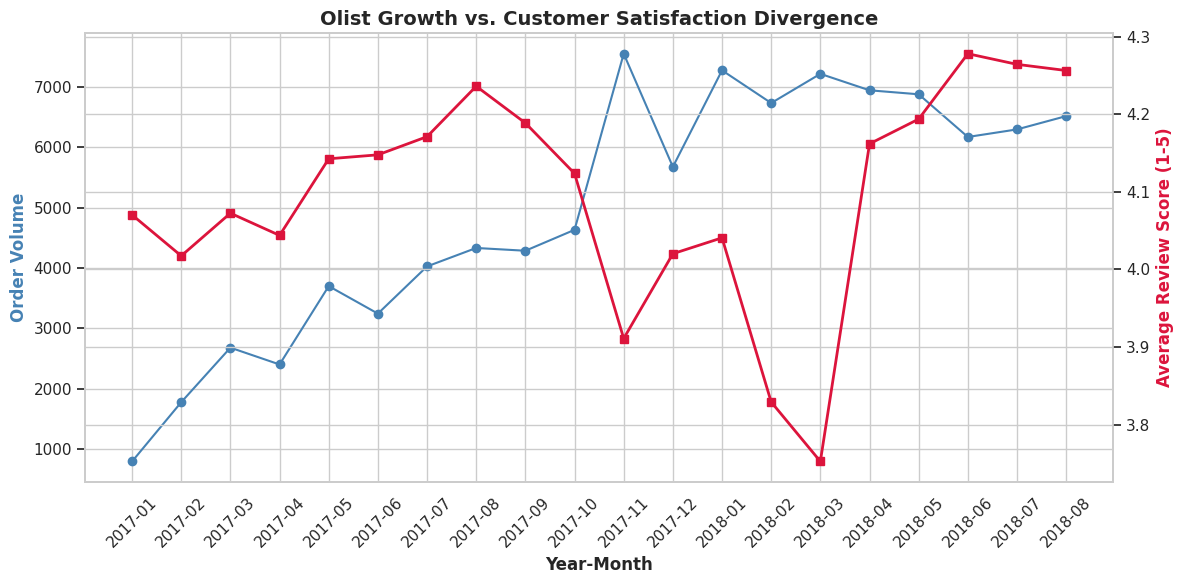

In [13]:
# 1. Extract Year-Month for grouping
df_orders['year_month'] = df_orders['order_purchase_timestamp'].dt.to_period('M')

# 2. Aggregate Revenue per order
monthly_rev = df_order_payments.groupby('order_id')['payment_value'].sum().reset_index()
monthly_rev = pd.merge(df_orders[['order_id', 'year_month']], monthly_rev, on='order_id', how='left')

# 3. Aggregate Reviews
monthly_reviews = pd.merge(df_orders[['order_id', 'year_month']], df_order_reviews[['order_id', 'review_score']], on='order_id', how='left')

# 4. Combine into final summary
q1_summary = monthly_rev.groupby('year_month').agg(
    order_volume=('order_id', 'count'),
    revenue=('payment_value', 'sum')
).reset_index()
q1_summary['avg_review'] = monthly_reviews.groupby('year_month')['review_score'].mean().values

# Filter out trailing months where data collection stopped
q1_summary = q1_summary[(q1_summary['year_month'] >= '2017-01') & (q1_summary['year_month'] <= '2018-08')]
q1_summary['year_month_str'] = q1_summary['year_month'].astype(str)

# --- Visualization ---
fig, ax1 = plt.subplots(figsize=(12, 6))
ax2 = ax1.twinx()

ax1.plot(q1_summary['year_month_str'], q1_summary['order_volume'], color='steelblue', marker='o', label='Order Volume')
ax2.plot(q1_summary['year_month_str'], q1_summary['avg_review'], color='crimson', marker='s', linewidth=2, label='Avg Review Score')

ax1.set_xlabel("Year-Month", fontweight='bold')
ax1.set_ylabel("Order Volume", color='steelblue', fontweight='bold')
ax2.set_ylabel("Average Review Score (1-5)", color='crimson', fontweight='bold')
ax1.tick_params(axis='x', rotation=45)
plt.title("Olist Growth vs. Customer Satisfaction Divergence", fontsize=14, fontweight='bold')
fig.tight_layout()
plt.show()

# Q2 & Q6 — Delivery Delays and Root Cause Analysis

--- Impact of Delays on Review Scores ---


,late_tier,avg_review,order_count
0,On Time / Early,4.293578,88658
1,1-7 Days Late,3.183830,4428
2,8-14 Days Late,1.749858,1759
3,15+ Days Late,1.710040,1514


/tmp/ipykernel_2099/4138400412.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  barplot = sns.barplot(data=tier_summary, x='late_tier', y='avg_review', palette='Reds_d')


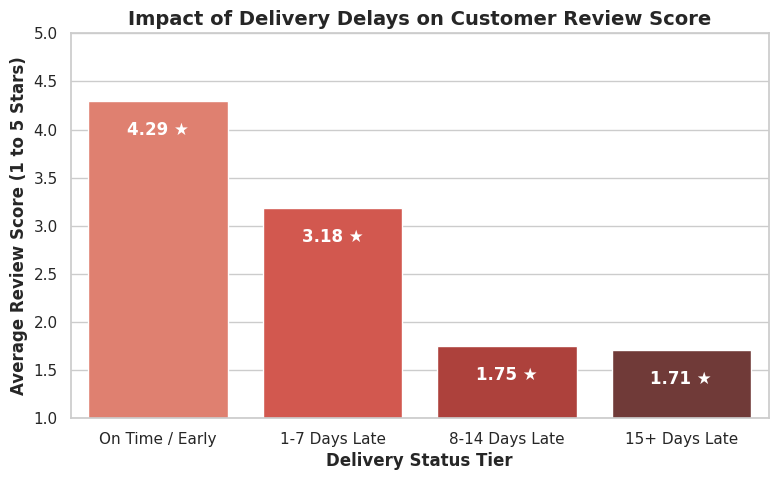

In [14]:
# Merge reviews with our cleaned delivered orders
q2_df = pd.merge(df_delivered, df_order_reviews[['order_id', 'review_score']], on='order_id', how='inner')

# Calculate the drop in review scores as orders get later
tier_summary = q2_df.groupby('late_tier', observed=False).agg(
    avg_review=('review_score', 'mean'),
    order_count=('review_score', 'count')
).reset_index()

print("--- Impact of Delays on Review Scores ---")
display(tier_summary)

# --- Visualization ---
plt.figure(figsize=(9, 5))
barplot = sns.barplot(data=tier_summary, x='late_tier', y='avg_review', palette='Reds_d')
plt.title("Impact of Delivery Delays on Customer Review Score", fontsize=14, fontweight='bold')
plt.xlabel("Delivery Status Tier", fontweight='bold')
plt.ylabel("Average Review Score (1 to 5 Stars)", fontweight='bold')
plt.ylim(1, 5)

# Add text labels on the bars
for p in barplot.patches:
    barplot.annotate(f"{p.get_height():.2f} ★",
                     (p.get_x() + p.get_width() / 2., p.get_height() - 0.35),
                     ha='center', color='white', fontweight='bold')
plt.show()

# Q3 — Seller & Geographic Patterns

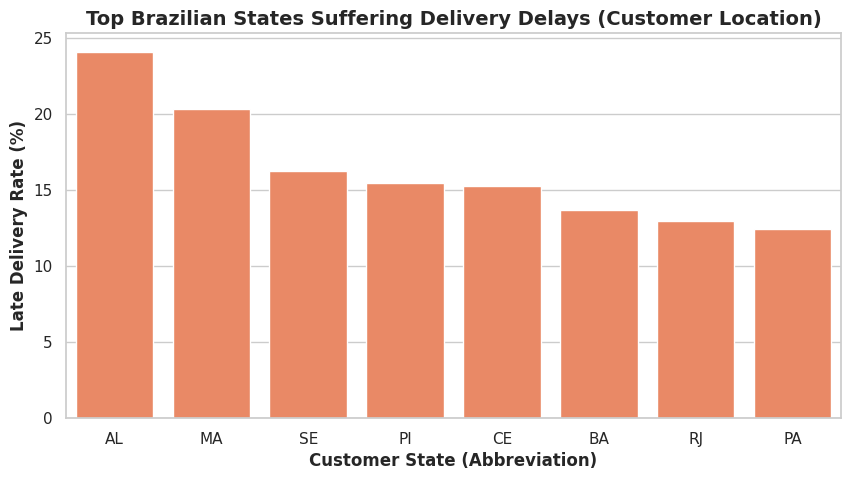

In [15]:
# 1. Build the Master Geographic Table
geo_df = pd.merge(df_delivered[['order_id', 'customer_id', 'is_late']], df_customers[['customer_id', 'customer_state']], on='customer_id', how='inner')
geo_df = pd.merge(geo_df, df_order_items[['order_id', 'seller_id', 'freight_value']], on='order_id', how='inner')
geo_df = pd.merge(geo_df, df_sellers[['seller_id', 'seller_state']], on='seller_id', how='inner')

# 2. Flag Cross-State Shipping
geo_df['cross_state'] = geo_df['customer_state'] != geo_df['seller_state']

# 3. Analyze Worst Performing States (Minimum 100 orders)
state_perf = geo_df.groupby('customer_state').agg(
    total_orders=('order_id', 'count'),
    late_rate=('is_late', lambda x: (x.sum() / x.count()) * 100)
).reset_index()
worst_states = state_perf[state_perf['total_orders'] > 100].sort_values(by='late_rate', ascending=False).head(8)

# --- Visualization ---
plt.figure(figsize=(10, 5))
sns.barplot(data=worst_states, x='customer_state', y='late_rate', color='coral')
plt.title("Top Brazilian States Suffering Delivery Delays (Customer Location)", fontsize=14, fontweight='bold')
plt.xlabel("Customer State (Abbreviation)", fontweight='bold')
plt.ylabel("Late Delivery Rate (%)", fontweight='bold')
plt.show()

# Q4 — Product Category Performance

In [16]:
# 1. Merge all product and review data together
cat_df = pd.merge(df_order_items, df_products, on='product_id', how='inner')
cat_df = pd.merge(cat_df, df_product_category, on='product_category_name', how='left')
cat_df = pd.merge(cat_df, df_order_reviews[['order_id', 'review_score']], on='order_id', how='inner')

# 2. Aggregate by Category
cat_summary = cat_df.groupby('product_category_name_english').agg(
    items_sold=('order_item_id', 'count'),
    avg_weight_kg=('product_weight_g', lambda x: x.mean() / 1000),
    avg_freight=('freight_value', 'mean'),
    avg_review=('review_score', 'mean')
).reset_index()

# Filter for significant volume (>500 items)
cat_filtered = cat_summary[cat_summary['items_sold'] > 500].sort_values(by='avg_review')

print("--- 5 Weakest Categories (Notice the Weights/Freight) ---")
display(cat_filtered.head(5))

print("\n--- 5 Strongest Categories ---")
display(cat_filtered.tail(5).sort_values(by='avg_review', ascending=False))

--- 5 Weakest Categories (Notice the Weights/Freight) ---


,product_category_name_english,items_sold,avg_weight_kg,avg_freight,avg_review
57,office_furniture,1687,11.392549,40.400148,3.493183
7,bed_bath_table,11137,2.118429,18.390023,3.895663
39,furniture_decor,8331,2.653907,20.718732,3.903493
40,furniture_living_room,502,8.064181,35.555080,3.904382
15,computers_accessories,7849,0.897882,18.805584,3.930819



--- 5 Strongest Categories ---


,product_category_name_english,items_sold,avg_weight_kg,avg_freight,avg_review
8,books_general_interest,549,0.759781,16.622769,4.446266
53,luggage_accessories,1088,5.761860,27.860956,4.315257
66,stationery,2507,2.739458,18.580000,4.193857
60,pet_shop,1939,2.901513,20.299603,4.185147
44,home_appliances,806,1.925320,19.263164,4.172457


# Q5 — Payment Behavior & Financing

--- The Impact of Installments on Order Value ---


,installment_tier,order_count,avg_order_value,avg_review
0,1 (Paid in Full),24960,101.168311,4.151002
1,2-3,22660,135.755502,4.086408
2,4-6,16166,182.071835,4.062229
3,7-10,11809,335.279611,4.000169
4,11+,340,344.999147,3.888235


/tmp/ipykernel_2099/1441193845.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=inst_analysis, x='installment_tier', y='avg_order_value', palette='viridis')


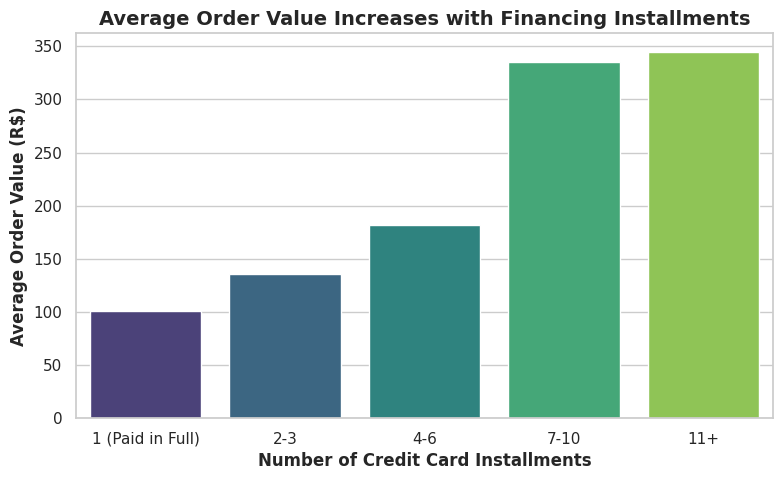

In [17]:
# 1. Aggregate payments to the order level
pay_agg = df_order_payments.groupby('order_id').agg(
    total_val=('payment_value', 'sum'),
    max_installments=('payment_installments', 'max'),
    payment_type=('payment_type', lambda x: x.mode()[0] if not x.mode().empty else 'unknown')
).reset_index()

# 2. Merge with reviews
pay_merged = pd.merge(pay_agg, df_order_reviews[['order_id', 'review_score']], on='order_id', how='inner')

# 3. Analyze Credit Card Installments
cc_data = pay_merged[pay_merged['payment_type'] == 'credit_card'].copy()
cc_data['installment_tier'] = pd.cut(
    cc_data['max_installments'],
    bins=[0, 1, 3, 6, 10, 24],
    labels=['1 (Paid in Full)', '2-3', '4-6', '7-10', '11+']
)

inst_analysis = cc_data.groupby('installment_tier', observed=False).agg(
    order_count=('order_id', 'count'),
    avg_order_value=('total_val', 'mean'),
    avg_review=('review_score', 'mean')
).reset_index()

print("--- The Impact of Installments on Order Value ---")
display(inst_analysis)

# --- Visualization ---
plt.figure(figsize=(9, 5))
sns.barplot(data=inst_analysis, x='installment_tier', y='avg_order_value', palette='viridis')
plt.title("Average Order Value Increases with Financing Installments", fontsize=14, fontweight='bold')
plt.xlabel("Number of Credit Card Installments", fontweight='bold')
plt.ylabel("Average Order Value (R$)", fontweight='bold')
plt.show()